# Tutorial 09: Planning through contacts

In this tutorial we look at using trajectory optimization with our hybrid systems.

**Pre-requisites**

Knowledge of contact modelling as discrete events, such as the case of the rimless wheel. Notions of optimization, both continuous and discrete.

**Goals**

Learning how to use optimization with hybrid systems, and on how to properly describe .

This notebook is organized as follows:

- 1. Introduction
- 2. Simulating through contacts
- 3. Limit cycle of the rimless wheel
- 4. Basketball trickshots
- 5. Optimization of the gait of a quadruped robot

## 1. Introduction

## 1.1 Hybrid dynamics

Hybrid systems are those which exhibit both continuous and discrete dynamics. One example is the Spring-Loaded Inverted Pendulum which we saw a few tutorials back.

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/SLIP_annotated.png" width="400"></div>
</div>

In order to understand more complex systems, we must first remember the nature of this system. The SLIP, depending on its mode, is subject to two different continuous dynamics (flying or in contact with the ground). To switch between the two, guards are used to detect when the mode should change. After the mode changes, we usually need to update our coordinates to reflect the result of the event that transitioned the system from one mode to another. These changes are usually referred to as resets.

Generally, the continuous dynamics of a hybrid system are described by

$$ \dot{x} = f(x, u).$$

With a transition map

$$x^+ = \Delta^i_{i+1}(x^-),$$
that is applied at the end of every phase. To determine when the transition map is activated, we define an **event function** $e_i(x)$ describes the conditions for the reset map application as

$$e(x) = 0,\ \dot e(x)<0.$$
## 1.2 Trajectory optimization

Previously, we have looked at trajectory optimization in systems that exhibit continuous dynamics.

Robots like the cartpole and simple and double pendulums exhibit continuous dynamics. This allows us to design and implement an optimization in which the system dynamics are the same at each instant.

We can formulate an optimal control problem for a (discretized) continuous system as 

$$
\begin{split}
\min_{x[.], u[.]} &\sum^{n=N}_{n=0} (J(n,x[n], u[n])\\
\text{s.t.} \quad &x[n+1] = f(x[n],u[n]) \\
&x[0] = x_0 \\
x_{min}\leq x[n] \leq x:{max}\\
u_{min}\leq u[n]\leq u_{max} \\
h(n, x[n], u[n])\leq 0\\
\end{split}
$$

## 1.3. The floating base

One last concept we should keep in mind to understand today's tutorial is the concept of the floating base. When using a floating base to describe a mechanism, we consider the robot as not being attached to the ground. To do so, we introduce a fictional joint with 6 degrees of freedom (3 in the 2D case) between the ground and the machine. The relation between the robot and the ground can then be modelled using constraints.

# 2. Simulating through contact
In the previous lecture block, we showed how hybrid systems can be modeled and simulated. The process is similar to that of continuous systems, except that we need to apply a transition/reset map and switch to the next continuous dynamics map when a corresponding event function reaches certain conditions, as shown in section 1.1.
<div style="display: flex; justify-content: space-around;">
    <div><img src="media/PCC_system.png" width="400"></div>
</div>
A problem we saw in those tutorials, is that it can be tough to determine the exact moment. Especially when working with large timesteps, the moment that a collision is reached can quickly be skipped over, leading to energy inconsistencies and instability of the simulation.

Without making the timestep excessively small, the solution to numerically find this point is to simply integrate backwards in time when we have crossed the event. Let's put this into practice with the simple system of a vertical bouncing ball.

The continuous dynamics of this system are:
$$ m\ddot{q} + mg = 0. $$

With event function

$$e(x) = x.$$

and transition function 

$$\Delta(x^-) = \begin{bmatrix}q \\ -\dot q \end{bmatrix}.$$

In [55]:
import numpy as np
import matplotlib.pyplot as plt
m = 1 # bouncing ball mass
g = 9.81 # gravity

def forward_dynamics(t, x):
    q, dq = x
    return  # Type here

def event_function(x):
    q, dq = x
    return  # Type here

def d_event_function(x):
    '''Derivative of the event function'''
    q, dq = x

    return dq # Type here

def reset_map(x):
    q, dq = x

    return  # Type here

Like in the previous tutorials, a fixed-step Runge Kutta will be used for the continuous dynamics.

Recall that RK4 is defined as:
$$
\mathbf{x}[n+1] = \mathbf{x}[n] + \frac{dt}{6}(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4)
$$

$$
t_{n+1} = t_n + dt
$$

where

$$
\begin{split}
\mathbf{k}_1  &=\mathbf{f}(t_{n}, \mathbf{x}_{n})\\
\mathbf{k}_2  &=\mathbf{f}(t_{n} + \frac{dt}{2}, \mathbf{x}_{n} + dt \frac{\mathbf{k}_1}{2})\\
\mathbf{k}_3  &=\mathbf{f}(t_{n} + \frac{dt}{2}, \mathbf{x}_{n} + dt \frac{\mathbf{k}_2}{2})\\
\mathbf{k}_4  &=\mathbf{f}(t_{n} + dt, \mathbf{x}_{n} + dt \mathbf{k}_3)\\
\end{split}
$$

In [56]:
def RK4(f, x, t, dt):
    
    k1 = f(t, x)
    k2 = f(t + 0.5*dt, x + 0.5*dt*k1)
    k3 = f(t + 0.5*dt, x + 0.5*dt*k2)
    k4 = f(t + dt, x + dt*k3)
    integ = (k1 + 2*(k2 + k3) + k4) / 6.0

    x_new = x + dt*integ

    return x_new

To get back to our previous implementation, all that is left is collision detection and simulation.

In [57]:
def collision_detection(x):
    e = event_function(x)
    de = d_event_function(x)

    if # type here!
        return True
    else:
        return False

def simulate(x0, te, dt = 1e-3):
    n = 1
    samples = int(te/dt)
    X = np.zeros([samples, 2*n])
    T = np.zeros(samples)
    X[0, :] = x0
    x = x0
    t = 0
    i = 0
    while t<te:
        # ---------
        # Type here!
        
        # ---------

        try:
            X[i, :] = x
            T[i] = t
        except:
            np.append(X, x)
            np.append(T, t)
        i += 1

    return T, X
        

If we simulate now, we will see the following happen:

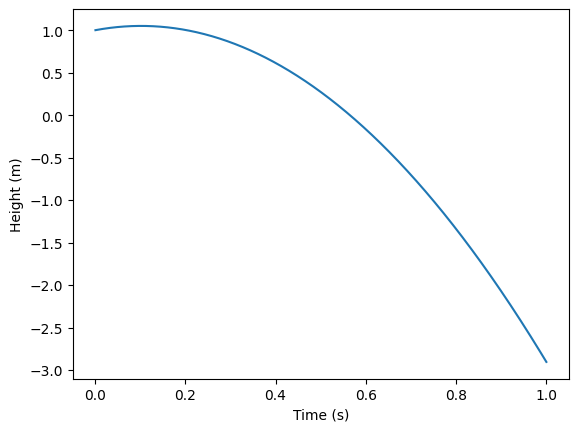

In [58]:
x0 = np.array([1.0, 1.0])
te = 1
T, X = simulate(x0, te)

plt.figure()
plt.plot(T, X[:, 0])
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.show()

What we were expecting is happening here; the event function condition is never truly triggered, as we miss the exact zero. To solve this, let us detect the crossing over zero event.

In [59]:
def crossing_detection(x):
    e = event_function(x)
    de = d_event_function(x)

    if # Type here!
        return True
    else:
        return False

Once we know that the crossing happened, we can start looking for the crossing between the current timestep and the previous timestep.

At this point, finding the correct time reduces to a root-finding function:
$$e(x) = 0. $$
Note that we cannot simply modify x until this holds, as the time should also be taken into account. For this, we need to integrate backwards and forwards in time iteratively and verify whether our event function approaches zero to a pre-determined tolerance.

One way of solving the root-finding problem is through the so-called **bisection method**.

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/bisection-method.png" width="320"> https://commons.wikimedia.org/wiki/File:Bisection_method.svg</div>
</div>

The bisection method consecutively splits the range defined by the left point $t_l$ and right point $t_r$ in half at midpoint $t_m$ and looks whether the **sign of the function $e(x)$** has changed. If the signs of the $t_l$ and $t_m$ are equal, the new interval is defined between $t_m$ and $t_r$. Otherwise, the new interval is defined between $t_l$ and $t_m$. 
The algorithm is interrupted when $|e(x(t_m))|<\epsilon$ where we choose $\epsilon$ as a predefined tolerance. We also stop when the interval gets too small, although this is unlikely to happen in our specific problem.

In our implementation, we can split the **time** in half, and compute x at that point in time.

Let's try and implement this!

In [60]:
def bisection_method(x_r, t_r, dt, tol = 1e-3, tol_interval = 1e-4):
    # Obtain the previous timestep and integrate backwards in time to obtain the previous state
    t_l = t_r - dt
    x_l = RK4(forward_dynamics, x_r, t_r, -dt)

    e_l = event_function(x_l)
    e_r = event_function(x_r)
    
    interval = dt
    t_mid = t_l + interval/2
    x_mid = RK4(forward_dynamics, x_l, t_l, interval/2) # Equal to the midpoint in this case
    e_mid = event_function(x_mid)
    while abs(e_mid) > tol and (t_r - t_l)>tol_interval:
        # ------
        # Type here!

        # ------

        interval = t_r - t_l
        t_mid = t_l + interval/2
        x_mid = RK4(forward_dynamics, x_l, t_l, interval/2)
        e_mid = event_function(x_mid)
    return x_mid, t_mid

Using this, we can modify our original simulation function and see that the results are now as expected!

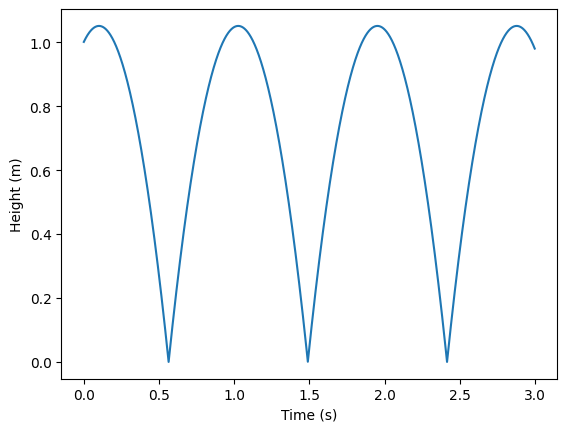

In [61]:
def simulate(x0, te, dt = 1e-3):
    n = 1
    samples = int(te/dt)
    X = np.zeros([samples, 2*n])
    T = np.zeros(samples)
    X[0, :] = x0
    x = x0
    t = 0
    i = 0
    while t<te:
        # ---------
        # Type here!

        # ---------   
        try:
            X[i, :] = x
            T[i] = t
        except:
            np.append(X, x)
            np.append(T, t)
        i += 1

    return T, X

x0 = np.array([1.0, 1.0])
te = 3
T, X = simulate(x0, te)

plt.figure()
plt.plot(T, X[:, 0])
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.show()

Many other root-finding methods exist and can be applied as well.

In the next sections, we will be using Drake rather than our own implementation. Since Drake uses Autodiff funcitonalities, the exact derivatives can be used in optimization, greatly improving speed. Furthermore, Drake provides access to a variety of solvers, which saves a lot of work. However, it is important to realize that similar algorithms as the ones we just implemented are used under the hood.

# 3. Limit cycle of the rimless wheel

<div style="display: flex; justify-content: space-around;">
    <div><img src="media/rimless.png" width="400"></div>
</div>

We can use optimization problems not only to actively control systems, but to explore their passive properties as well. When it comes to the rimless wheel, we already know that depending on its initial conditions, the system may enter an endless periodic motion. We can use trajectory optimization to find the limit cycle that characterizes this motion. We can do so by solving the following optimization problem:

$$
\begin{align*}
\begin{split}
  \text{find}_{\mathbf{x}[\cdot],h} \quad \text{subject to} \quad & \text{collocation
    constraints}(\mathbf{x}[n], \mathbf{x}[n+1], h), \quad \forall n \in [0, N-1] \\ &
    \theta[0] = \gamma - \alpha, \\ & \theta[N] = \gamma + \alpha, \\ &
    \dot\theta[0] = \dot\theta[N] \cos(2\alpha)\\ & h_{min} \le h \le h_{max}.  
\end{split}
\end{align*}
$$

## Think-Pair-Share (5 min)

Think about the constraints you would need to formulate to describe a limit cycle.

In [62]:
import matplotlib.pyplot as plt
import mpld3
import numpy as np
from IPython.display import display
from pydrake.all import DirectCollocation, MathematicalProgram, Solve
from pydrake.examples import RimlessWheel
mpld3.enable_notebook()

In [63]:
def rimless_wheel_limit_cycle():
    plant = RimlessWheel()
    context = plant.CreateDefaultContext()

    params = context.get_numeric_parameter(0)
    slope = params.slope()
    alpha = np.pi / params.number_of_spokes()

    dircol = DirectCollocation(
        plant,
        context,
        num_time_samples=15,
        minimum_time_step=0.01,
        maximum_time_step=0.1,
        assume_non_continuous_states_are_fixed=True,
    )
    prog = dircol.prog()

    dircol.AddEqualTimeIntervalsConstraints()
    # -----------------------------
    # Angle limit constraints
    # -----------------------------
    dircol.AddConstraintToAllKnotPoints(dircol.state()[0] >= slope - alpha)
    dircol.AddConstraintToAllKnotPoints(dircol.state()[0] <= slope + alpha)

    # -----------------------------
    # (Periodic) boundary constraints
    # -----------------------------
    prog.AddConstraint(dircol.initial_state()[0] == slope - alpha)
    prog.AddConstraint(dircol.final_state()[0] == slope + alpha)
    # Velocity
    prog.AddConstraint(
        dircol.initial_state()[1] == dircol.final_state()[1] * np.cos(2 * alpha)
    )

    result = Solve(prog)
    assert result.is_success()

    x_trajectory = dircol.ReconstructStateTrajectory(result)

    x_knots = np.hstack(
        [
            x_trajectory.value(t)
            for t in np.linspace(
                x_trajectory.start_time(), x_trajectory.end_time(), 100
            )
        ]
    )

    fig, ax = plt.subplots()
    ax.plot(x_knots[0, :], x_knots[1, :])
    ax.plot([x_knots[0, 0], x_knots[0, -1]], [x_knots[1, 0], x_knots[1, -1]], "--")

    # Plot the energy contours.
    nq = 151
    nqd = 151
    mgl = params.mass() * params.gravity() * params.length()
    q = np.linspace(-0.5, 0.5, nq)
    qd = np.linspace(-0.5, 2, nqd)
    Q, QD = np.meshgrid(q, qd)
    Energy = 0.5 * params.mass() * params.length() ** 2 * QD**2 + mgl * np.cos(Q)
    ax.contour(
        Q,
        QD,
        Energy,
        alpha=0.5,
        levels = 10,
        linestyles="dashed",
        colors="black",
        linewidths=0.5,
    )

    ax.set_xlabel("theta")
    ax.set_ylabel("dtheta")
    ax.axis([-0.5, 0.5, 0, 2])
    ax.set_title("Limit Cycle of the Rimless Wheel (w/ contours of " "constant energy)")
    display(mpld3.display())


rimless_wheel_limit_cycle()

Take a look at the graph above. What does the contour plot remind you of?

# 4. Basketball trickshots
At this point, let's move on to control problems. A simple system which we have discussed before, is the bouncing ball.

Our state vector for this problem is:

$$
\mathbf{q} = \begin{bmatrix}x \\
          z\end{bmatrix}
$$

During the parts of the trajectory in which the ball is not in contact with the ground, only gravity contributes to the dynamics of the system:

$$
 \ddot{\mathbf{q}} = \begin{bmatrix} 0 \\ -g
          \end{bmatrix}
$$

The simplicity of this system allows us to analytically integrate the dynamics between bounces, rather than relying on Forward Euler or RK algorithms.
To do so, we use the following dynamics equations:

$$
\mathbf{x}(t+h) = f(t+h) = \begin{bmatrix} x(t) + h\dot{x}(t) \\ z(t) + h
          \dot{z}(t) - \frac{1}{2}gh^2 \\ \dot{x}(t) \\ \dot{z}(t) - hg
          \end{bmatrix}.
$$

Our reset map after a bounce is:

$$
\mathbf{x}^+ = {\mathbf{f} \Delta(\mathbf{x}^-)} =
          \begin{bmatrix} x^- & z^- & \dot{x}^- & - e \dot{z}^-
          \end{bmatrix}^T.
$$
with $e$ denoting the coefficient of restitution.
### 4.1. Bounce pass
Let's say we want to throw the ball to a teammate that is a distance of $x_f$ metres away from us. To make it easy for our teammate, we determine that the ball must reach them at the same height that we throw it at, $z_f$. Essentially, this gives us a trajectory optimization problem subject to system dynamics and boundary constraints.
$$ \begin{split}
x(0) &= [x_f, z_f]^T, \\
x(T) &= [x_f, z_f]^T, \\
x(t) &= f(t).
\end{split}
$$
As long as the ball does not hit the ground, this is a standard optimization program. However, the moment we want to include a contact sequence, care must be taken in how to describe this mathematically. 

Luckily, this specific system allows for a big simplification: Since our dynamics can be integrated analytically, Only the initial throw and number of bounces need to be considered.

Let's see how this looks in code!

In [65]:
e = 0.8  # coefficient of restitution (0 ≤ e ≤ 1)
g = 9.8  # gravitational constant (m/s^2)
x0 = 0
xf = 4
z0 = 1
zf = 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_xlim(x0 - 0.1, xf + 0.1)


def bounce_pass(number_of_bounces=0, zdot0_is_positive=True, debug=False):
    duration = 2 + number_of_bounces
    xdot = (xf - x0) / duration
    prog = MathematicalProgram()
    h = prog.NewContinuousVariables(number_of_bounces + 1, "h")
    prog.AddConstraint(np.sum(h) == duration)
    prog.AddBoundingBoxConstraint(0, np.inf, h)

    # zdot at the start of each segment (after collision).
    zdot = prog.NewContinuousVariables(number_of_bounces + 1, "zd")

    # Initial velocity constraint (since we *might* have two solutions for each number of bounces)
    if zdot0_is_positive:
        prog.AddBoundingBoxConstraint(0, np.inf, zdot[0])
    else:
        prog.AddBoundingBoxConstraint(-np.inf, 0, zdot[0])

    # Add dynamics constraints for each segment that ends with a bounce
    for i in range(number_of_bounces):
        # z must be zero at the end of this segment:
        z = zdot[i] * h[i] - 0.5 * g * h[i] * h[i] + (z0 if i == 0 else 0)
        prog.AddConstraint(z == 0)
        prog.AddConstraint(zdot[i + 1] == -e * (zdot[i] - h[i] * g)) # Constrain the velocity at touchdown!

    # Now the final segment
    z = (
        zdot[-1] * h[-1]
        - 0.5 * g * h[-1] * h[-1]
        + (z0 if number_of_bounces == 0 else 0)
    )
    prog.AddConstraint(z == zf)

    result = Solve(prog)
    if not result.is_success():
        if debug:
            infeasible = result.GetInfeasibleConstraints(prog)
            print("Infeasible constraints:")
            for i in range(len(infeasible)):
                print(infeasible[i])
        # return without plotting
        return

    # plot the resulting trajectory
    ax.set_prop_cycle(plt.rcParams["axes.prop_cycle"])  # reset color cycle
    relative_time = np.linspace(0, 1, 10)
    x_start = x0
    for i in range(number_of_bounces + 1):
        t = result.GetSolution(h[i]) * relative_time
        x = x_start + t * xdot
        z = (z0 if i == 0 else 0) + result.GetSolution(zdot[i]) * t - 0.5 * g * t * t
        ax.plot(x, z, ".-")
        x_start = x[-1]
# bounce_pass(number_of_bounces=2, zdot0_is_positive=False, debug=True)
'''
for number_of_bounces in range(0, 4):
    bounce_pass(number_of_bounces=number_of_bounces, zdot0_is_positive=True)
    bounce_pass(number_of_bounces=number_of_bounces, zdot0_is_positive=False)
'''
bounce_pass(number_of_bounces=0, zdot0_is_positive=True)

display(mpld3.display())

### 4.2. Trick shot

The goal now is to first bounce the ball off a wall, then hit the ground, and, finally, have it fall in the hoop. To perform our trickshot, we will need to take into account the spin of the ball. It only affects the bounce. To do so, we need to add $\theta$ to our state vector:

$$
\mathbf{q} = \begin{bmatrix}x \\
          z \\ \theta \end{bmatrix}
$$

Our new equations of motion are of the form

$$ M(q)\ddot{q} = G + J^T\lambda.$$
Where $G$ denotes the constant gravity. $J$ denotes the jacobian of the contact constraints. Because we are now considering spin, we include the rotational inertia, which is $I=\frac{2}{3}r^2$. Thus, the full EOMs now become

$$
\begin{split}
          \begin{bmatrix} m & 0 & 0 \\ 0 & m & 0 \\ 0 & 0 & \frac{2}{3}mr^2
          \end{bmatrix} \ddot{\mathbf{q}} =\begin{bmatrix} 0 \\ -g \\ 0 \end{bmatrix} +
          \begin{bmatrix} 0 & 1 \\ 1 & 0 \\ 0 & r \end{bmatrix} \begin{bmatrix}
          \lambda_z \\ \lambda_x \end{bmatrix}.
\end{split}
$$

Then, the reset map taking into account the spin is:

$$
\dot{\mathbf{q}}^+ = \begin{bmatrix} \frac{3}{5} & 0 &
          -\frac{2}{5} r \\ 0 & - e & 0 \\ -\frac{3}{5r} & 0 &
          \frac{2}{5}\end{bmatrix}\dot{\mathbf{q}}^-.
$$

In [67]:
def trick_shot():
    r = 0.1
    g = 9.8  # gravitational constant (m/s^2)
    e = 0.8  # coefficient of restitution (0 ≤ e ≤ 1)
    x0 = -0.25
    xf = -1
    z0 = 1
    zf = 3

    N = 3
    prog = MathematicalProgram()
    h = prog.NewContinuousVariables(N)
    # Make sure time intervals are positive:
    prog.AddBoundingBoxConstraint(0.01, 10, h)

    # zdot at the start of each segment (after collision).
    xdot = prog.NewContinuousVariables(N)
    zdot = prog.NewContinuousVariables(N)
    thetadot = prog.NewContinuousVariables(N)

    # First segment -- from the launch to the wall.
    # Implement the guard (x==0).
    prog.AddConstraint(x0 + h[0] * xdot[0] == 0).evaluator().set_description("x_wall")
    z = z0 + h[0] * zdot[0] - 0.5 * g * h[0] * h[0]
    zdot_pre = zdot[0] - g * h[0]
    # integration + collision dynamics
    prog.AddConstraint(xdot[1] == -e * xdot[0]).evaluator().set_description("xdot_wall")
    prog.AddConstraint(
        zdot[1] == 3.0 * zdot_pre / 5.0 - 2.0 * r * thetadot[0] / 5.0
    ).evaluator().set_description("zdot_wall")
    prog.AddConstraint(
        thetadot[1] == -3 * zdot_pre / (5.0 * r) + 2.0 * thetadot[0] / 5.0
    ).evaluator().set_description("thetadot_wall")
    # Help it find the solution we want
    prog.AddConstraint(zdot[0] >= 0)
    prog.AddConstraint(thetadot[0] <= 0)

    # Second segment -- from wall to the floor
    z = z + zdot[1] * h[1] - 0.5 * g * h[1] * h[1]
    # Implement the guard (z==0).
    prog.AddConstraint(z == 0).evaluator().set_description("z_floor")
    x = xdot[1] * h[1]
    zdot_pre = zdot[1] - g * h[1]
    # integration + collision dynamics
    prog.AddConstraint(
        xdot[2] == 3.0 * xdot[1] / 5.0 - 2.0 * r * thetadot[1] / 5.0
    ).evaluator().set_description("xdot_floor")
    prog.AddConstraint(zdot[2] == -e * zdot_pre).evaluator().set_description(
        "zdot_floor"
    )
    prog.AddConstraint(
        thetadot[2] == -3 * xdot[1] / (5.0 * r) + 2.0 * thetadot[1] / 5.0
    ).evaluator().set_description("thetadot_floor")
    # Make sure the ball doesn't travel too far away
    prog.AddConstraint(x >= -3.0)

    # Final segment -- from the floor to the hoop
    x = x + xdot[2] * h[2]
    z = zdot[2] * h[2] - 0.5 * g * h[2] * h[2]
    # make sure we end at the hoop.
    prog.AddConstraint(x == xf).evaluator().set_description("x_hoop")
    prog.AddConstraint(z == zf).evaluator().set_description("z_hoop")
    zdot_final = zdot[2] - g * h[2]
    # make sure we're approaching from the correct direction.
    prog.AddConstraint(xdot[2] >= 0.1).evaluator().set_description("xdot_hoop")
    prog.AddConstraint(zdot_final <= -2).evaluator().set_description("zdot_hoop")

    result = Solve(prog)
    if not result.is_success():
        infeasible = result.GetInfeasibleConstraints(prog)
        print("Infeasible constraints:")
        for i in range(len(infeasible)):
            print(infeasible[i])

        # plot the resulting trajectory
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    # ax.set_xlim(x0-.1, xf+.1)
    ax.set_prop_cycle(plt.rcParams["axes.prop_cycle"])  # reset color cycle
    relative_time = np.linspace(0, 1, 10)
    x_start = x0
    z_start = z0
    for i in range(N):
        t = result.GetSolution(h[i]) * relative_time
        x = x_start + result.GetSolution(xdot[i]) * t
        z = z_start + result.GetSolution(zdot[i]) * t - 0.5 * g * t * t
        ax.plot(x, z, ".-")
        x_start = x[-1]
        z_start = z[-1]

    print("Rotation rate during each segment:")
    print(result.GetSolution(thetadot))
    display(mpld3.display())


trick_shot()

Rotation rate during each segment:
[-48.90510626 -74.74551176 -19.74881645]


## Think-Pair-Share (5 min)

- 1. Think about both the bounce pass and trickshot. What information **not related to collision** was needed beforehand to perform this problem?
- 2. Try modifying the previous cell to make your own trickshot. Try adding more bounces, for instance.

# 5. Optimization of the gait of a quadruped robot

One way of incorporating discrete events, such as contacts into our optimization is to provide the time and/or location of the contacts. In this way, our optimization problem is actually a series of optimal control problems with different dynamics depending on the feet that are currently in contact. These are joined into a single problem by introducing constraints that enforce continuity between the dynamics modes. This is set of mode changes is then known as a **fixed mode sequence**.

In [68]:
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import math 
import sympy as sym
import time

from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    AddUnitQuaternionConstraintOnPlant,
    AutoDiffXd,
    DiagramBuilder,
    ExtractGradient,
    ExtractValue,
    InitializeAutoDiff,
    JacobianWrtVariable,
    JointIndex,
    MathematicalProgram,
    MeshcatVisualizer,
    OrientationConstraint,
    Parser,
    PidController,
    PiecewisePolynomial,
    PositionConstraint,
    RotationMatrix,
    Simulator,
    SnoptSolver,
    Solve,
    StartMeshcat,
    eq,
    namedview,
)


%matplotlib inline
from IPython.display import HTML, IFrame, display
from pinocchio.utils import rotate
from pinocchio import Quaternion
from robomeshcat import Object, Scene, Robot

In [69]:
scene = Scene(wait_for_open=False)
display(IFrame(scene.vis.url(), width="100%", height=400))
r = Robot(urdf_path="model/LittleDog-visual.urdf")
g = Robot(urdf_path="model/ground-visual.urdf")
scene.add_robot(r)
scene.add_robot(g)
r.pos = np.array([0.0, 0.0, 0.125])

cam_pos = np.array([0.5, 2, 0.5])
scene.camera_pos = cam_pos
scene.camera_zoom = 4
scene.vis.set_cam_target([0, 0, 0.1])

You can open the visualizer by visiting the following URL:
https://cloudpendulum.m2.chalmers.se:1443/user/sahand_wag/proxy/7057/static/


We can run any generated trajectories in the following script.

In [73]:
for q in trajectory[::1000]:

        # floating base
        base_pos = q[4:7]
        base_quat = q[0:4].flatten()
        r.pos = base_pos.flatten()

        w, x, y, z = base_quat
        r.rot = Quaternion(x, y, z, w).toRotationMatrix()

        # joints
        for name, idx in joint_map:
            r[name] = q[idx]
        time.sleep(1e-4/1000)

Let's try simulating a simple PID. Run the following script to record the movement, and then the script above to see what happens.

In [71]:
def set_home(plant, context):
    PositionView = namedview(
        "Positions",
        plant.GetPositionNames(
            plant.GetModelInstanceByName("LittleDog"), always_add_suffix=False
        ),
    )
    hip_roll = 0.1
    hip_pitch = 1
    knee = 1.55
    q0 = PositionView(np.zeros(plant.num_positions()))
    q0.front_right_hip_roll = -hip_roll
    q0.front_right_hip_pitch = hip_pitch
    q0.front_right_knee = -knee
    q0.front_left_hip_roll = hip_roll
    q0.front_left_hip_pitch = hip_pitch
    q0.front_left_knee = -knee
    q0.back_right_hip_roll = -hip_roll
    q0.back_right_hip_pitch = -hip_pitch
    q0.back_right_knee = knee
    q0.back_left_hip_roll = hip_roll
    q0.back_left_hip_pitch = -hip_pitch
    q0.back_left_knee = knee
    # 180 deg yaw correction
    q0.body_qw = 1
    q0.body_qx = 0
    q0.body_qy = 0
    q0.body_qz = 0
    q0.body_z = 0.146
    plant.SetPositions(context, q0[:])


def run_pid_control():
    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, 1e-3)

    parser = Parser(plant)
    parser.AddModels("model/ground.urdf")
    parser.AddModels("model/LittleDog.urdf")
    plant.Finalize()

    # -----------------------------
    # Build joint map for trajectory recording
    # -----------------------------
    joint_names = []
    for i in range(plant.num_joints()):
        joint = plant.get_joint(JointIndex(i))
        if joint.num_positions() == 1: # Check if this is a rotational, 1-dof joint
            joint_names.append(joint.name())

    # -----------------------------
    # PID gains
    # -----------------------------
    actuators = plant.num_actuators()
    kp = 1.0*np.ones(actuators)
    ki = 0.0*np.ones(actuators)
    kd = 0.1*np.ones(actuators)

    # -----------------------------
    # Correct state projection matrix S
    # -----------------------------
    num_q = plant.num_positions()
    num_v = plant.num_velocities()
    state_size = plant.num_multibody_states()

    S = np.zeros((2 * actuators, state_size)) # Twice the amount of actuators, since velocity is included

    j = 0
    for i in range(plant.num_joints()):
        joint = plant.get_joint(JointIndex(i))

        if joint.num_positions() != 1: # Check if this is indeed a rotational, 1-dof Joint
            continue

        # position index
        q_idx = joint.position_start()

        # velocity index
        v_idx = joint.velocity_start()

        S[j, q_idx] = 1
        S[actuators + j, num_q + v_idx] = 1

        # knee tuning
        if "knee" in joint.name():
            kd[j] = 0.1
        j += 1

    # -----------------------------
    # Actuation matrix and setting up the PID control
    # -----------------------------
    B = plant.MakeActuationMatrix()

    control = builder.AddSystem(
        PidController(
            kp=kp,
            ki=ki,
            kd=kd,
            state_projection=S,
            output_projection=B[6:, :].T,
        )
    )

    builder.Connect(
        plant.get_state_output_port(),
        control.get_input_port_estimated_state()
    )

    builder.Connect(
        control.get_output_port(),
        plant.get_actuation_input_port()
    )

    diagram = builder.Build()
    simulator = Simulator(diagram)

    context = simulator.get_mutable_context()
    plant_context = plant.GetMyContextFromRoot(context)

    set_home(plant, plant_context)

    # -----------------------------
    # Desired state
    # -----------------------------
    x = plant.get_state_output_port().Eval(plant_context)
    x0 = S @ x

    control.get_input_port_desired_state().FixValue(
        control.GetMyContextFromRoot(context),
        x0
    )

    # -----------------------------
    # Simulation
    # -----------------------------
    trajectory = []

    dt = 1e-4
    T = 5.0
    t = 0.0

    while t < T:
        simulator.AdvanceTo(t + dt)

        q = plant.GetPositions(plant_context)
        trajectory.append(q.copy())

        t += dt
    # -----------------------------
    # Replay
    # -----------------------------
    joint_map = []
    for i in range(plant.num_joints()):
        joint = plant.get_joint(JointIndex(i))
        if joint.num_positions() == 1:
            joint_map.append((joint.name(), joint.position_start()))

    return joint_map, trajectory

joint_map, trajectory = run_pid_control()

To avoid For the next part of this section, we will purely look at trajectory generation, rather than simulation.

![](https://upload.wikimedia.org/wikipedia/commons/4/4f/Gait_graphs_v2.png)

## Think-Pair-Share (10 min)

Think about the different types of constraints you would need to create a quadruped gait. Think about limits on joints, orientations, contacts, etc.

In [74]:
%%capture
# Need this because a==b returns True even if a = AutoDiffXd(1, [1, 2]), b= AutoDiffXd(2, [3, 4])
# That's the behavior of AutoDiffXd in C++, also.


def autoDiffArrayEqual(a, b):
    return np.array_equal(a, b) and np.array_equal(
        ExtractGradient(a), ExtractGradient(b)
    )


def gait_optimization(gait="walking_trot"):
    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, 1e-3)
    parser = Parser(plant)
    littledog = parser.AddModels("model/LittleDog.urdf")[0]
    plant.Finalize()

    diagram = builder.Build()
    context = diagram.CreateDefaultContext()
    plant_context = plant.GetMyContextFromRoot(context)
    set_home(plant, plant_context)

    q0 = plant.GetPositions(plant_context)
    body_frame = plant.GetFrameByName("body")

    PositionView = namedview(
        "Positions", plant.GetPositionNames(littledog, always_add_suffix=False)
    )
    VelocityView = namedview(
        "Velocities",
        plant.GetVelocityNames(littledog, always_add_suffix=False),
    )

    mu = 1  # No slip friction
    total_mass = plant.CalcTotalMass(plant_context, [littledog])
    gravity = plant.gravity_field().gravity_vector()

    nq = 12
    foot_frame = [
        plant.GetFrameByName("front_left_foot_center"),
        plant.GetFrameByName("front_right_foot_center"),
        plant.GetFrameByName("back_left_foot_center"),
        plant.GetFrameByName("back_right_foot_center"),
    ]

    # setup gait
    is_laterally_symmetric = False
    check_self_collision = False
    if gait == "running_trot":
        N = 21
        in_stance = np.zeros((4, N))
        in_stance[1, 3:17] = 1
        in_stance[2, 3:17] = 1
        speed = 0.9
        stride_length = 0.55
        is_laterally_symmetric = True
    elif gait == "walking_trot":
        N = 21
        in_stance = np.zeros((4, N))
        in_stance[0, :11] = 1
        in_stance[1, 8:N] = 1
        in_stance[2, 8:N] = 1
        in_stance[3, :11] = 1
        speed = 0.4
        stride_length = 0.25
        is_laterally_symmetric = True
    elif gait == "rotary_gallop":
        N = 41
        in_stance = np.zeros((4, N))
        in_stance[0, 7:19] = 1
        in_stance[1, 3:15] = 1
        in_stance[2, 24:35] = 1
        in_stance[3, 26:38] = 1
        speed = 1
        stride_length = 0.65
        check_self_collision = True
    elif gait == "bound":
        N = 41
        in_stance = np.zeros((4, N))
        in_stance[0, 6:18] = 1
        in_stance[1, 6:18] = 1
        in_stance[2, 21:32] = 1
        in_stance[3, 21:32] = 1
        speed = 1.2
        stride_length = 0.55
        check_self_collision = True
    else:
        raise RuntimeError("Unknown gait.")

    T = stride_length / speed
    if is_laterally_symmetric:
        T = T / 2.0

    prog = MathematicalProgram()

    # -----------------------------
    # Define timestep as a decision variable
    # Add X constraints
    # -----------------------------
    h = prog.NewContinuousVariables(N - 1, "h")
    prog.AddBoundingBoxConstraint(0.5 * T / N, 2.0 * T / N, h)
    prog.AddLinearConstraint(sum(h) >= 0.9 * T)
    prog.AddLinearConstraint(sum(h) <= 1.1 * T)

    # Create one context per time step (to maximize cache hits)
    context = [plant.CreateDefaultContext() for i in range(N)]
    # We could get rid of this by implementing a few more Jacobians in MultibodyPlant:
    ad_plant = plant.ToAutoDiffXd()

    # -----------------------------
    # Joint positions and velocities
    # Initialize the decision variables q and v
    # -----------------------------
    nq = plant.num_positions()
    nv = plant.num_velocities()
    q = prog.NewContinuousVariables(nq, N, "q")
    v = prog.NewContinuousVariables(nv, N, "v")
    q_view = PositionView(q)
    v_view = VelocityView(v)
    q0_view = PositionView(q0)
    # Joint costs
    q_cost = PositionView([1] * nq)
    v_cost = VelocityView([1] * nv)
    q_cost.body_x = 0
    q_cost.body_y = 0
    q_cost.body_qx = 0
    q_cost.body_qy = 0
    q_cost.body_qz = 0
    q_cost.body_qw = 0
    q_cost.front_left_hip_roll = 5
    q_cost.front_right_hip_roll = 5
    q_cost.back_left_hip_roll = 5
    q_cost.back_right_hip_roll = 5
    v_cost.body_vx = 0
    v_cost.body_wx = 0
    v_cost.body_wy = 0
    v_cost.body_wz = 0

    # -----------------------------
    # Add X as constraints
    # -----------------------------
    for n in range(N):
        # Joint limits
        prog.AddBoundingBoxConstraint(
            plant.GetPositionLowerLimits(),
            plant.GetPositionUpperLimits(),
            q[:, n],
        )
        # Joint velocity limits
        prog.AddBoundingBoxConstraint(
            plant.GetVelocityLowerLimits(),
            plant.GetVelocityUpperLimits(),
            v[:, n],
        )
        # Unit quaternions
        AddUnitQuaternionConstraintOnPlant(plant, q[:, n], prog)
        # -----------------------------
        # X constraint (keep in orientation with world)
        # -----------------------------
        prog.AddConstraint(
            OrientationConstraint(
                plant,
                body_frame,
                RotationMatrix(),
                plant.world_frame(),
                RotationMatrix(),
                0.1,
                context[n],
            ),
            q[:, n],
        )
        # Initial guess for all joint angles is the home position
        prog.SetInitialGuess(
            q[:, n], q0
        )  # Solvers get stuck if the quaternion is initialized with all zeros.

        # Running costs:
        prog.AddQuadraticErrorCost(np.diag(q_cost), q0, q[:, n])
        prog.AddQuadraticErrorCost(np.diag(v_cost), [0] * nv, v[:, n])

    # Make a new autodiff context for this constraint (to maximize cache hits)
    ad_velocity_dynamics_context = [ad_plant.CreateDefaultContext() for i in range(N)]

    # -----------------------------
    # X constraints (ensure velocities are physically consitent)
    # -----------------------------
    def velocity_dynamics_constraint(vars, context_index):
        h, q, v, qn = np.split(vars, [1, 1 + nq, 1 + nq + nv])
        if isinstance(vars[0], AutoDiffXd):
            if not autoDiffArrayEqual(
                q,
                ad_plant.GetPositions(ad_velocity_dynamics_context[context_index]),
            ):
                ad_plant.SetPositions(ad_velocity_dynamics_context[context_index], q)
            v_from_qdot = ad_plant.MapQDotToVelocity(
                ad_velocity_dynamics_context[context_index], (qn - q) / h
            )
        else:
            if not np.array_equal(q, plant.GetPositions(context[context_index])):
                plant.SetPositions(context[context_index], q)
            v_from_qdot = plant.MapQDotToVelocity(context[context_index], (qn - q) / h)
        return v - v_from_qdot

    for n in range(N - 1):
        prog.AddConstraint(
            partial(velocity_dynamics_constraint, context_index=n),
            lb=[0] * nv,
            ub=[0] * nv,
            vars=np.concatenate(([h[n]], q[:, n], v[:, n], q[:, n + 1])),
        )

    # -----------------------------
    # Contact forces are decision variables
    # -----------------------------
    contact_force = [
        prog.NewContinuousVariables(3, N - 1, f"foot{foot}_contact_force")
        for foot in range(4)
    ]
    # -----------------------------
    # X constraints (No slip)
    # -----------------------------
    for n in range(N - 1):
        for foot in range(4):
            # Linear friction cone
            prog.AddLinearConstraint(
                contact_force[foot][0, n] <= mu * contact_force[foot][2, n]
            )
            prog.AddLinearConstraint(
                -contact_force[foot][0, n] <= mu * contact_force[foot][2, n]
            )
            prog.AddLinearConstraint(
                contact_force[foot][1, n] <= mu * contact_force[foot][2, n]
            )
            prog.AddLinearConstraint(
                -contact_force[foot][1, n] <= mu * contact_force[foot][2, n]
            )
            # normal force >=0, normal_force == 0 if not in_stance

            # -----------------------------
            # Contact constraint for gait timings!!
            # -----------------------------
            prog.AddBoundingBoxConstraint(
                0,
                in_stance[foot, n] * 4 * 9.81 * total_mass,
                contact_force[foot][2, n],
            )

    
    # -----------------------------
    # X constraints (on position and velocity)
    # -----------------------------
    com = prog.NewContinuousVariables(3, N, "com")
    comdot = prog.NewContinuousVariables(3, N, "comdot")
    comddot = prog.NewContinuousVariables(3, N - 1, "comddot")
    # Initial CoM x,y position == 0
    prog.AddBoundingBoxConstraint(0, 0, com[:2, 0])
    # Initial CoM z vel == 0
    prog.AddBoundingBoxConstraint(0, 0, comdot[2, 0])
    # CoM height
    prog.AddBoundingBoxConstraint(0.125, np.inf, com[2, :])
    # CoM x velocity >= 0
    prog.AddBoundingBoxConstraint(0, np.inf, comdot[0, :])
    # CoM final x position
    if is_laterally_symmetric:
        prog.AddBoundingBoxConstraint(
            stride_length / 2.0, stride_length / 2.0, com[0, -1]
        )
    else:
        prog.AddBoundingBoxConstraint(stride_length, stride_length, com[0, -1])

        # -----------------------------
        # Dynamics constraints
        # 1. states should be consistent over time x[i] & x[i+1], which is done through forward euler.
        # 2. states should be consistent at instantaneous time (According to centroidal dynamics)
        # -----------------------------
    
    # -----------------------------
    # X constraints (Centroidal model)
    # -----------------------------
    for n in range(N - 1):
        # Note: The original matlab implementation used backwards Euler (here and throughout),
        # which is a little more consistent with the LCP contact models.
        prog.AddConstraint(eq(com[:, n + 1], com[:, n] + h[n] * comdot[:, n]))
        prog.AddConstraint(eq(comdot[:, n + 1], comdot[:, n] + h[n] * comddot[:, n]))
        prog.AddConstraint(
            eq(
                total_mass * comddot[:, n],
                sum(contact_force[i][:, n] for i in range(4)) + total_mass * gravity,
            )
        )

    # -----------------------------
    # X constraints (Centroidal model)
    # -----------------------------
    H = prog.NewContinuousVariables(3, N, "H")
    Hdot = prog.NewContinuousVariables(3, N - 1, "Hdot")
    prog.SetInitialGuess(H, np.zeros((3, N)))
    prog.SetInitialGuess(Hdot, np.zeros((3, N - 1)))

    # Hdot = sum_i cross(p_FootiW-com, contact_force_i)
    def angular_momentum_constraint(vars, context_index):
        q, com, Hdot, contact_force = np.split(vars, [nq, nq + 3, nq + 6])
        contact_force = contact_force.reshape(3, 4, order="F")
        if isinstance(vars[0], AutoDiffXd):
            dq = ExtractGradient(q)
            q = ExtractValue(q)
            if not np.array_equal(q, plant.GetPositions(context[context_index])):
                plant.SetPositions(context[context_index], q)
            torque = np.zeros(3)
            for i in range(4):
                p_WF = plant.CalcPointsPositions(
                    context[context_index],
                    foot_frame[i],
                    [0, 0, 0],
                    plant.world_frame(),
                )
                Jq_WF = plant.CalcJacobianTranslationalVelocity(
                    context[context_index],
                    JacobianWrtVariable.kQDot,
                    foot_frame[i],
                    [0, 0, 0],
                    plant.world_frame(),
                    plant.world_frame(),
                )
                ad_p_WF = InitializeAutoDiff(p_WF, Jq_WF @ dq)
                torque = torque + np.cross(
                    ad_p_WF.reshape(3) - com, contact_force[:, i]
                )
        else:
            if not np.array_equal(q, plant.GetPositions(context[context_index])):
                plant.SetPositions(context[context_index], q)
            torque = np.zeros(3)
            for i in range(4):
                p_WF = plant.CalcPointsPositions(
                    context[context_index],
                    foot_frame[i],
                    [0, 0, 0],
                    plant.world_frame(),
                )
                torque += np.cross(p_WF.reshape(3) - com, contact_force[:, i])
        return Hdot - torque

    for n in range(N - 1):
        prog.AddConstraint(eq(H[:, n + 1], H[:, n] + h[n] * Hdot[:, n]))
        Fn = np.concatenate([contact_force[i][:, n] for i in range(4)])
        prog.AddConstraint(
            partial(angular_momentum_constraint, context_index=n),
            lb=np.zeros(3),
            ub=np.zeros(3),
            vars=np.concatenate((q[:, n], com[:, n], Hdot[:, n], Fn)),
        )

    # com == CenterOfMass(q), H = SpatialMomentumInWorldAboutPoint(q, v, com)
    # Make a new autodiff context for this constraint (to maximize cache hits)
    com_constraint_context = [ad_plant.CreateDefaultContext() for i in range(N)]

    def com_constraint(vars, context_index):
        qv, com, H = np.split(vars, [nq + nv, nq + nv + 3])
        if isinstance(vars[0], AutoDiffXd):
            if not autoDiffArrayEqual(
                qv,
                ad_plant.GetPositionsAndVelocities(
                    com_constraint_context[context_index]
                ),
            ):
                ad_plant.SetPositionsAndVelocities(
                    com_constraint_context[context_index], qv
                )
            com_q = ad_plant.CalcCenterOfMassPositionInWorld(
                com_constraint_context[context_index], [littledog]
            )
            H_qv = ad_plant.CalcSpatialMomentumInWorldAboutPoint(
                com_constraint_context[context_index], [littledog], com
            ).rotational()
        else:
            if not np.array_equal(
                qv, plant.GetPositionsAndVelocities(context[context_index])
            ):
                plant.SetPositionsAndVelocities(context[context_index], qv)
            com_q = plant.CalcCenterOfMassPositionInWorld(
                context[context_index], [littledog]
            )
            H_qv = plant.CalcSpatialMomentumInWorldAboutPoint(
                context[context_index], [littledog], com
            ).rotational()
        return np.concatenate((com_q - com, H_qv - H))

    for n in range(N):
        prog.AddConstraint(
            partial(com_constraint, context_index=n),
            lb=np.zeros(6),
            ub=np.zeros(6),
            vars=np.concatenate((q[:, n], v[:, n], com[:, n], H[:, n])),
        )

    # -----------------------------
    # X constraints
    # 1. Foot should be on the ground during stance
    # 2. Foot should not move on the ground (no slip)
    # 3. Foot should be above the ground during slip
    # -----------------------------
    def fixed_position_constraint(vars, context_index, frame):
        q, qn = np.split(vars, [nq])
        if not np.array_equal(q, plant.GetPositions(context[context_index])):
            plant.SetPositions(context[context_index], q)
        if not np.array_equal(qn, plant.GetPositions(context[context_index + 1])):
            plant.SetPositions(context[context_index + 1], qn)
        p_WF = plant.CalcPointsPositions(
            context[context_index], frame, [0, 0, 0], plant.world_frame()
        )
        p_WF_n = plant.CalcPointsPositions(
            context[context_index + 1], frame, [0, 0, 0], plant.world_frame()
        )
        if isinstance(vars[0], AutoDiffXd):
            J_WF = plant.CalcJacobianTranslationalVelocity(
                context[context_index],
                JacobianWrtVariable.kQDot,
                frame,
                [0, 0, 0],
                plant.world_frame(),
                plant.world_frame(),
            )
            J_WF_n = plant.CalcJacobianTranslationalVelocity(
                context[context_index + 1],
                JacobianWrtVariable.kQDot,
                frame,
                [0, 0, 0],
                plant.world_frame(),
                plant.world_frame(),
            )
            return InitializeAutoDiff(
                p_WF_n - p_WF,
                J_WF_n @ ExtractGradient(qn) - J_WF @ ExtractGradient(q),
            )
        else:
            return p_WF_n - p_WF

    for i in range(4):
        for n in range(N):
            if in_stance[i, n]:
                # foot should be on the ground (world position z=0)
                prog.AddConstraint(
                    PositionConstraint(
                        plant,
                        plant.world_frame(),
                        [-np.inf, -np.inf, 0],
                        [np.inf, np.inf, 0],
                        foot_frame[i],
                        [0, 0, 0],
                        context[n],
                    ),
                    q[:, n],
                )
                if n > 0 and in_stance[i, n - 1]:
                    # feet should not move during stance.
                    prog.AddConstraint(
                        partial(
                            fixed_position_constraint,
                            context_index=n - 1,
                            frame=foot_frame[i],
                        ),
                        lb=np.zeros(3),
                        ub=np.zeros(3),
                        vars=np.concatenate((q[:, n - 1], q[:, n])),
                    )
            else:
                min_clearance = 0.01
                prog.AddConstraint(
                    PositionConstraint(
                        plant,
                        plant.world_frame(),
                        [-np.inf, -np.inf, min_clearance],
                        [np.inf, np.inf, np.inf],
                        foot_frame[i],
                        [0, 0, 0],
                        context[n],
                    ),
                    q[:, n],
                )

    # -----------------------------
    # X constraints (symmetries in gait, so gait-dependent)
    # -----------------------------
    if is_laterally_symmetric:
        # Joints
        def AddAntiSymmetricPair(a, b):
            prog.AddLinearEqualityConstraint(a[0] == -b[-1])
            prog.AddLinearEqualityConstraint(a[-1] == -b[0])

        def AddSymmetricPair(a, b):
            prog.AddLinearEqualityConstraint(a[0] == b[-1])
            prog.AddLinearEqualityConstraint(a[-1] == b[0])

        AddAntiSymmetricPair(q_view.front_left_hip_roll, q_view.front_right_hip_roll)
        AddSymmetricPair(q_view.front_left_hip_pitch, q_view.front_right_hip_pitch)
        AddSymmetricPair(q_view.front_left_knee, q_view.front_right_knee)
        AddAntiSymmetricPair(q_view.back_left_hip_roll, q_view.back_right_hip_roll)
        AddSymmetricPair(q_view.back_left_hip_pitch, q_view.back_right_hip_pitch)
        AddSymmetricPair(q_view.back_left_knee, q_view.back_right_knee)
        prog.AddLinearEqualityConstraint(q_view.body_y[0] == -q_view.body_y[-1])
        prog.AddLinearEqualityConstraint(q_view.body_z[0] == q_view.body_z[-1])

        # -----------------------------
        # Task constraints (The robot should move forwards)
        # -----------------------------
        # Body orientation must be in the xz plane:
        prog.AddBoundingBoxConstraint(0, 0, q_view.body_qx[[0, -1]])
        prog.AddBoundingBoxConstraint(0, 0, q_view.body_qz[[0, -1]])

        # Floating base velocity
        prog.AddLinearEqualityConstraint(v_view.body_vx[0] == v_view.body_vx[-1])
        prog.AddLinearEqualityConstraint(v_view.body_vy[0] == -v_view.body_vy[-1])
        prog.AddLinearEqualityConstraint(v_view.body_vz[0] == v_view.body_vz[-1])

        # CoM velocity
        prog.AddLinearEqualityConstraint(comdot[0, 0] == comdot[0, -1])
        prog.AddLinearEqualityConstraint(comdot[1, 0] == -comdot[1, -1])
        prog.AddLinearEqualityConstraint(comdot[2, 0] == comdot[2, -1])

    else:
        # Everything except body_x is periodic
        q_selector = PositionView([True] * nq)
        q_selector.body_x = False
        prog.AddLinearConstraint(eq(q[q_selector, 0], q[q_selector, -1]))
        prog.AddLinearConstraint(eq(v[:, 0], v[:, -1]))

    # TODO: Set solver parameters (mostly to make the worst case solve times less bad)
    snopt = SnoptSolver().solver_id()
    prog.SetSolverOption(snopt, "Iterations Limits", 1e5)
    prog.SetSolverOption(
        snopt, "Major Iterations Limit", 200
    )
    prog.SetSolverOption(snopt, "Major Feasibility Tolerance", 5e-6)
    prog.SetSolverOption(snopt, "Major Optimality Tolerance", 1e-4)
    prog.SetSolverOption(snopt, "Superbasics limit", 2000)
    prog.SetSolverOption(snopt, "Linesearch tolerance", 0.9)
    # prog.SetSolverOption(snopt, 'Print file', 'snopt.out')

    # TODO a few more costs/constraints from
    # from https://github.com/RobotLocomotion/LittleDog/blob/master/gaitOptimization.m

    result = Solve(prog)
    print(result.get_solver_id().name())
    # print(result.is_success())  # We expect this to be false if iterations are limited.

    def HalfStrideToFullStride(a):
        b = PositionView(np.copy(a))

        b.body_y = -a.body_y
        # Mirror quaternion so that roll=-roll, yaw=-yaw
        b.body_qx = -a.body_qx
        b.body_qz = -a.body_qz

        b.front_left_hip_roll = -a.front_right_hip_roll
        b.front_right_hip_roll = -a.front_left_hip_roll
        b.back_left_hip_roll = -a.back_right_hip_roll
        b.back_right_hip_roll = -a.back_left_hip_roll

        b.front_left_hip_pitch = a.front_right_hip_pitch
        b.front_right_hip_pitch = a.front_left_hip_pitch
        b.back_left_hip_pitch = a.back_right_hip_pitch
        b.back_right_hip_pitch = a.back_left_hip_pitch

        b.front_left_knee = a.front_right_knee
        b.front_right_knee = a.front_left_knee
        b.back_left_knee = a.back_right_knee
        b.back_right_knee = a.back_left_knee

        return b

    # -----------------------------------
    # Trajectory recording (no Meshcat)
    # -----------------------------------
    context = diagram.CreateDefaultContext()
    plant_context = plant.GetMyContextFromRoot(context)
    
    t_sol = np.cumsum(np.concatenate(([0], result.GetSolution(h))))
    q_sol = PiecewisePolynomial.FirstOrderHold(t_sol, result.GetSolution(q))
    
    trajectory = []
    
    num_strides = 4
    t0 = t_sol[0]
    tf = t_sol[-1]
    T = tf * num_strides * (2.0 if is_laterally_symmetric else 1.0)
    
    dt = 1.0 / 32.0
    t = t0
    
    while t <= T:
        context.SetTime(t)
    
        stride = (t - t0) // (tf - t0)
        ts = (t - t0) % (tf - t0)
    
        qt = PositionView(q_sol.value(ts))
    
        if is_laterally_symmetric:
            if stride % 2 == 1:
                qt = HalfStrideToFullStride(qt)
                qt.body_x += stride_length / 2.0
            stride = stride // 2
    
        qt.body_x += stride * stride_length
    
        plant.SetPositions(plant_context, qt[:])
    
        trajectory.append(qt[:].copy())
    
        t += dt
    
    return trajectory


# Try them all!  The last three could use a little tuning.
trajectory = gait_optimization("walking_trot")
#trajectory = gait_optimization("running_trot")
#trajectory = gait_optimization('rotary_gallop')
#trajectory = gait_optimization('bound')

Below, you can visualize the constraints

In [97]:
scene = Scene(wait_for_open=False)
display(IFrame(scene.vis.url(), width="100%", height=400))
r = Robot(urdf_path="model/LittleDog-collisions.urdf")
g = Robot(urdf_path="model/ground-visual.urdf")
scene.add_robot(r)
scene.add_robot(g)
r.pos = np.array([0.0, 0.0, 0.125])

cam_pos = np.array([0.5, 2, 0.5])
scene.camera_pos = cam_pos
scene.camera_zoom = 4
scene.vis.set_cam_target([0, 0, 0.1])

You can open the visualizer by visiting the following URL:
https://cloudpendulum.m2.chalmers.se:1443/user/sahand_wag/proxy/7062/static/


In [101]:
# Show the trajectory
dt = 1/32.0
for q in trajectory:

        # floating base
        base_pos = q[4:7]
        base_quat = q[0:4].flatten()
        r.pos = base_pos.flatten()

        w, x, y, z = base_quat
        r.rot = Quaternion(x, y, z, w).toRotationMatrix()

        # joints
        for name, idx in joint_map:
            r[name] = q[idx]
        time.sleep(dt)